In [2]:
import sys

sys.path.append("..")

import importlib

import scripts.utils1 as utils1

importlib.reload(utils1)

<module 'scripts.utils1' from '/home/rupin/ERA5_LSTM_Project/notebooks/../scripts/utils1.py'>

In [3]:
df_dev = utils1.load_period_file(
    "Delhi_1980_2020.txt"
)

df_future = utils1.load_period_file(
    "Delhi_2021_2025.txt"
)

print(df_dev.shape)
print(df_future.shape)

df_dev.head()

(14976, 2)
(1826, 2)


,date,temperature
0,1980-01-01,13.9228
1,1980-01-02,12.6549
2,1980-01-03,11.0885
3,1980-01-04,11.5423
4,1980-01-05,11.3894


In [5]:
dev_scaled, scaler = (
    utils1.scale_development_data(df_dev)
)

future_scaled = (
    utils1.transform_future_data(
        df_future,
        scaler
    )
)

print(dev_scaled.shape)
print(future_scaled.shape)

(14976, 1)
(1826, 1)


In [6]:
sequence_length = 30

X_dev, y_dev = utils1.create_sequences(
    dev_scaled,
    sequence_length
)

X_future, y_future = utils1.create_sequences(
    future_scaled,
    sequence_length
)

print("Development:", X_dev.shape)
print("Future:", X_future.shape)

Development: (14946, 30, 1)
Future: (1796, 30, 1)


In [7]:
print(X_dev[0].shape)

print(y_dev[0])

print(X_dev[0][:5])

(30, 1)
[0.19644499]
[[0.20185348]
 [0.16362929]
 [0.11640604]
 [0.13008704]
 [0.12547746]]


In [8]:
train_size = int(len(X_dev)*0.8)

X_train = X_dev[:train_size]
X_test = X_dev[train_size:]

y_train = y_dev[:train_size]
y_test = y_dev[train_size:]

print(X_train.shape)
print(X_test.shape)

(11956, 30, 1)
(2990, 30, 1)


In [10]:
import pandas as pd
dates_dev = pd.to_datetime(df_dev["date"])

test_start_date = dates_dev.iloc[
    sequence_length + train_size
]

print(test_start_date)

2012-10-25 00:00:00


In [11]:
model = utils1.build_model(
    sequence_length
)

model.summary()

E0000 00:00:1780908790.254753    1467 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.0058 - val_loss: 0.0025
Epoch 2/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 3/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 4/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 5/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 7/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 8/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0011 - val_loss: 9.9858e-04
Epoch 9/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.0010 - val_loss: 9.8891e-04
Epoch 10/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0010 - val_loss: 9.8545e-04
Epoch 11/20
374/374 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0010 - val_loss: 9.8315e-04
Epoch 12/20
37

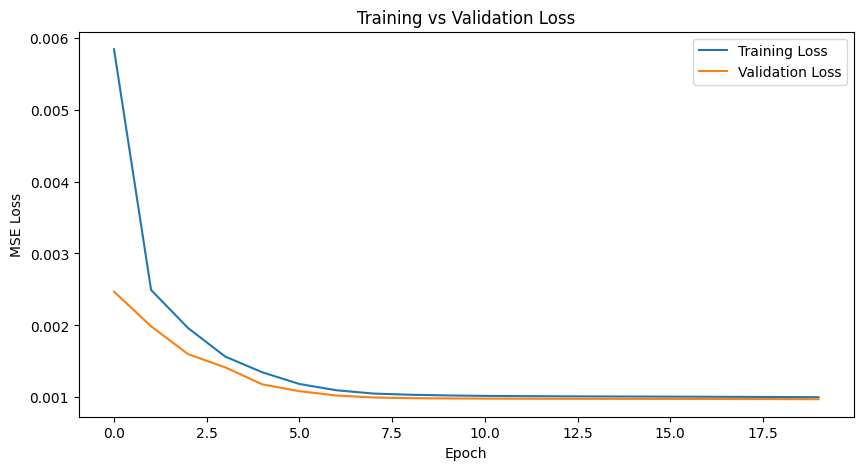

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.show()

In [14]:
pred_test = model.predict(X_test)

pred_test = scaler.inverse_transform(
    pred_test
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [16]:
import numpy as np
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        pred_test
    )
)

mae = mean_absolute_error(
    y_test_actual,
    pred_test
)

corr = np.corrcoef(
    y_test_actual.flatten(),
    pred_test.flatten()
)[0,1]

r2 = r2_score(
    y_test_actual,
    pred_test
)

print("RMSE:", rmse)
print("MAE:", mae)
print("Correlation:", corr)
print("R²:", r2)

RMSE: 1.0354117726405252
MAE: 0.7808420346847582
Correlation: 0.9885760854678433
R²: 0.9771270015522852


In [21]:
test_dates = (
    df_dev["date"]
    .iloc[sequence_length + train_size:]
    .reset_index(drop=True)
)

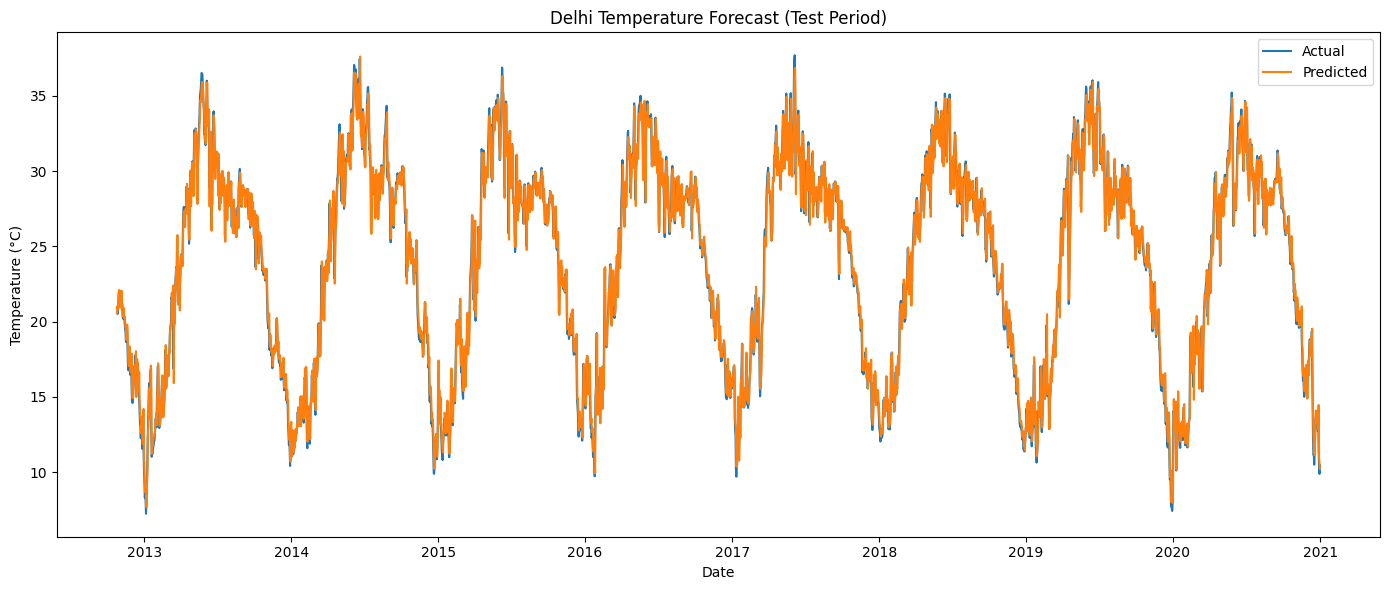

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    y_test_actual.flatten(),
    label="Actual"
)

plt.plot(
    test_dates,
    pred_test.flatten(),
    label="Predicted"
)

plt.title(
    "Delhi Temperature Forecast (Test Period)"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

In [17]:
pred_future = model.predict(
    X_future
)

pred_future = scaler.inverse_transform(
    pred_future
)

y_future_actual = scaler.inverse_transform(
    y_future.reshape(-1,1)
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [18]:
future_rmse = np.sqrt(
    mean_squared_error(
        y_future_actual,
        pred_future
    )
)

future_mae = mean_absolute_error(
    y_future_actual,
    pred_future
)

future_corr = np.corrcoef(
    y_future_actual.flatten(),
    pred_future.flatten()
)[0,1]

future_r2 = r2_score(
    y_future_actual,
    pred_future
)

print("Future RMSE:", future_rmse)
print("Future MAE:", future_mae)
print("Future Correlation:", future_corr)
print("Future R²:", future_r2)

Future RMSE: 1.049363973701906
Future MAE: 0.7895997796625769
Future Correlation: 0.9873571841589199
Future R²: 0.9747607196862613


In [19]:
future_dates = df_future["date"].iloc[30:].reset_index(drop=True)

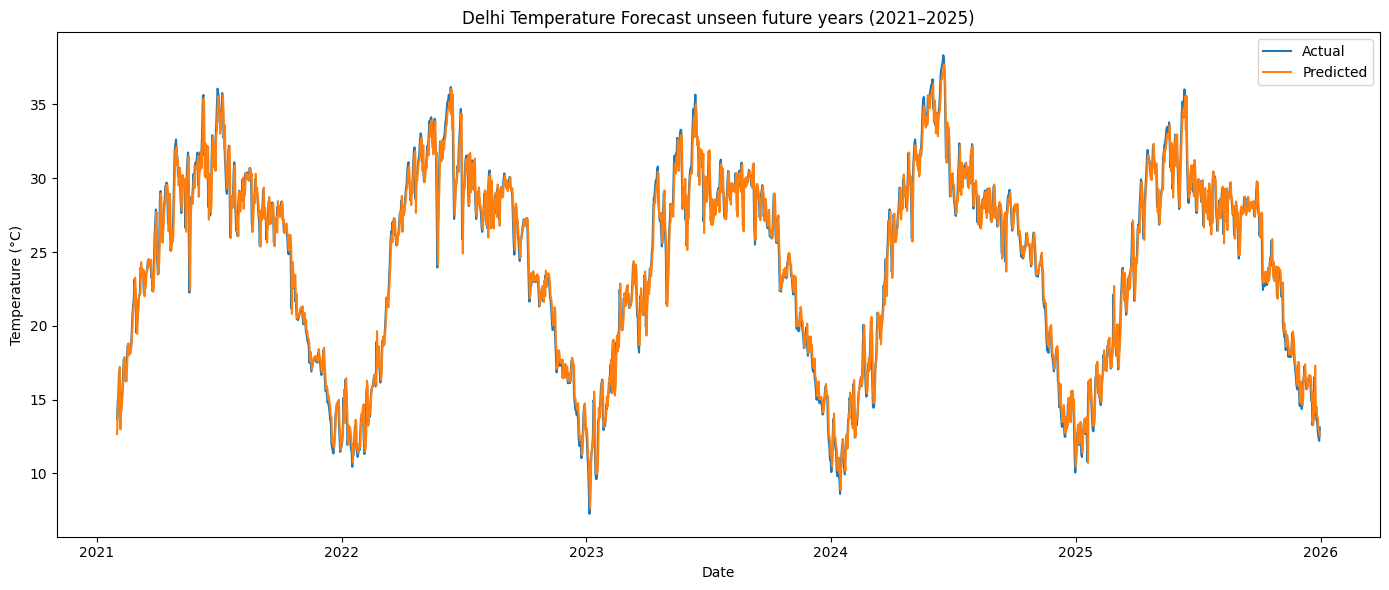

In [23]:
plt.figure(figsize=(14,6))

plt.plot(
    future_dates,
    y_future_actual,
    label="Actual"
)

plt.plot(
    future_dates,
    pred_future,
    label="Predicted"
)

plt.title(
    "Delhi Temperature Forecast unseen future years (2021–2025)"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()